<a href="https://colab.research.google.com/github/kelvin-yg98/Python-Individual-Project/blob/main/individual_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- First 12 Rows ---


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
Total duplicate rows found: 0

--- Missing Values Per Column ---
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year      

,show_id,type,title,director,cast,country,rating,duration,listed_in,description,primary_country
count,8797,8797,8797,8797,8797,8797,8797,8794,8797,8797,8797
unique,8797,2,8797,4529,7683,749,17,220,513,8765,87
top,s8807,Movie,Zubaan,Unknown,Unknown,United States,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope...",United States
freq,1,6131,1,2624,825,2812,3205,1793,362,4,3205



--- Numerical Summary ---


,date_added,release_year,year_added
count,8797,8797.000000,8797.000000
mean,2019-05-17 05:59:08.436966912,2014.183472,2018.871888
min,2008-01-01 00:00:00,1925.000000,2008.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000
50%,2019-07-02 00:00:00,2017.000000,2019.000000
75%,2020-08-19 00:00:00,2019.000000,2020.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000
std,NaN,8.822191,1.574243


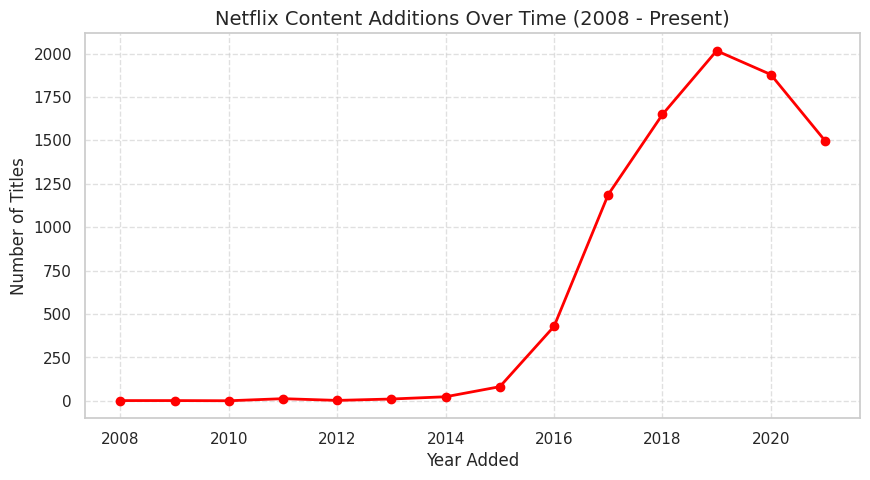

/tmp/ipykernel_16002/3020360105.py:95: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')


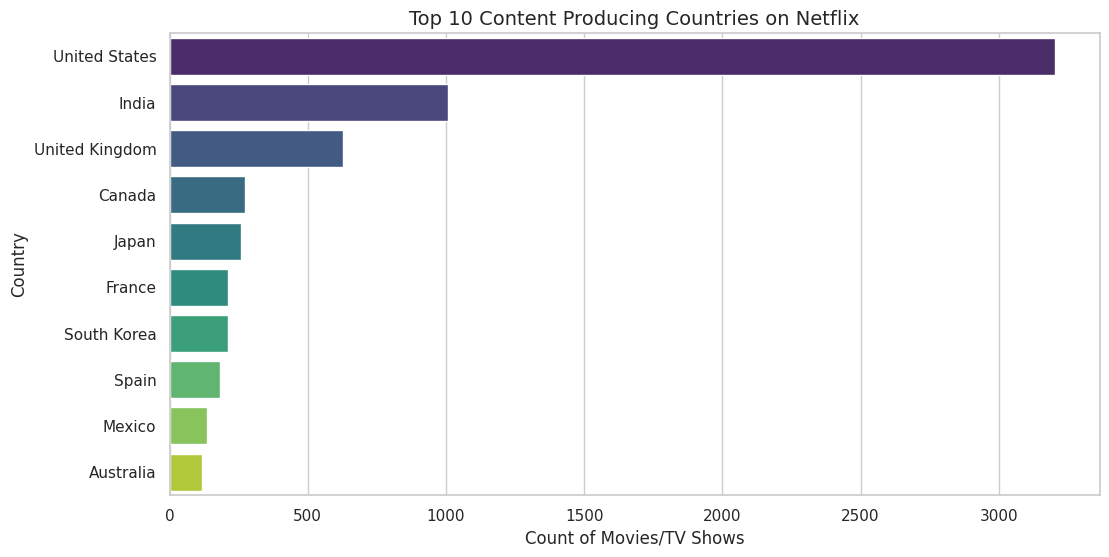

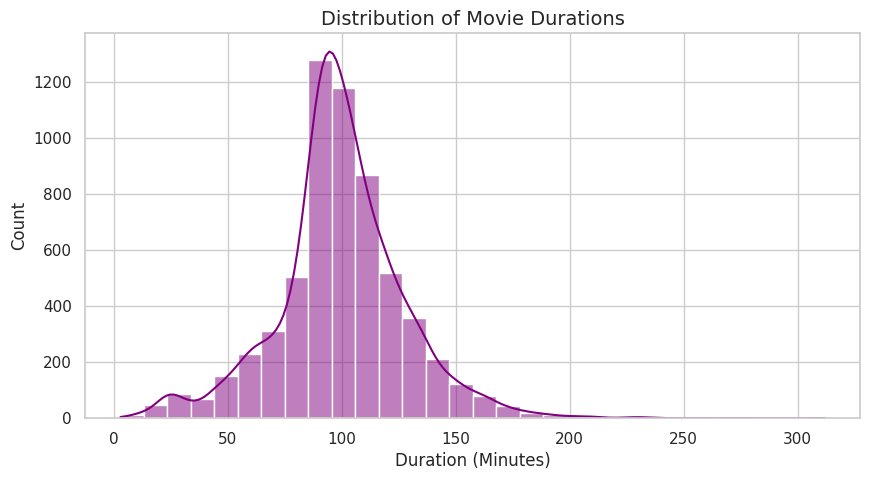

/tmp/ipykernel_16002/3020360105.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=recent_content, x='type', y='release_year', palette='pastel')


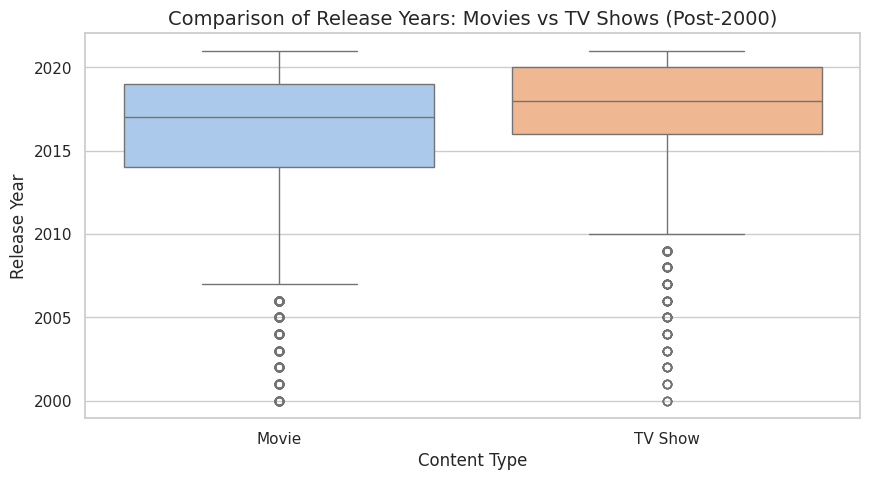

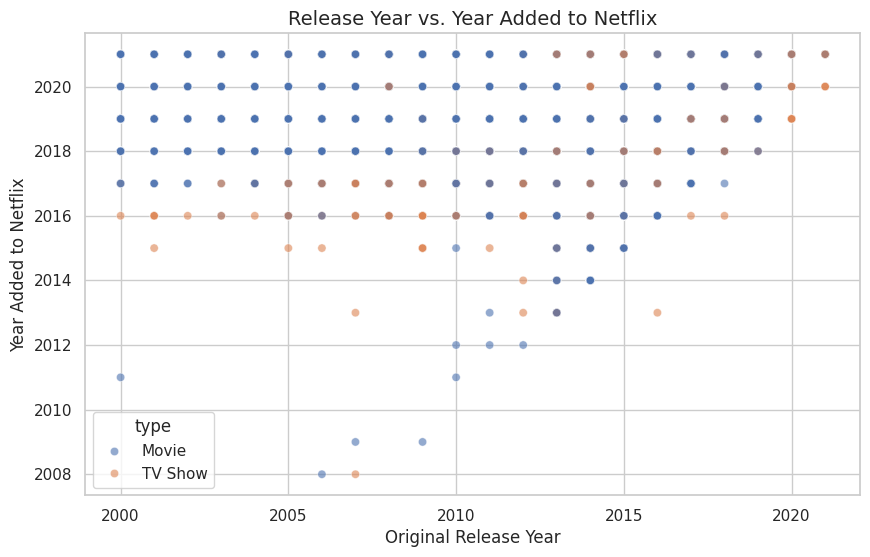

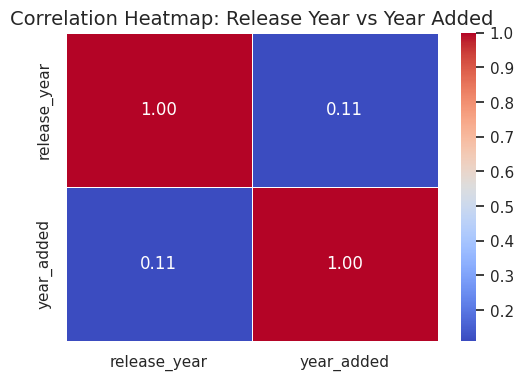

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("netflix_titles.csv")

print("--- First 12 Rows ---")
display(df.head())


print("\n--- Dataset Info ---")
df.info()



#CLEANING

print(f"Total duplicate rows found: {df.duplicated().sum()}")

print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

df['rating'] = df['rating'].fillna('UR')

df.dropna(subset=['date_added'], inplace=True)

df['date_added'] = pd.to_datetime(df['date_added'].astype(str).str.strip())

print("\n--- Missing Values After Cleaning ---")
print(df.isnull().sum())


#INSERTING TABLES

df['year_added'] = df['date_added'].dt.year

df['primary_country'] = df['country'].apply(lambda x: x.split(',')[0])

print("\nCalculated columns added successfully!")
df[['title', 'date_added', 'year_added', 'country', 'primary_country']].head()


# Explanation
# year_added: Extracted from the exact calendar date to allow us to observe Netflix's content acquisition behavior year-over-year.
# primary_country: Standardizes the country field by isolating the lead producing country, eliminating the messiness of multi-nation co-productions for cleaner charting.


print("--- Categorical Summary ---")
display(df.describe(include='O'))

print("\n--- Numerical Summary ---")
display(df.describe())


# Analytical Question,Required Chart Type & Tool
#Q1. How has the amount of content added to Netflix changed over the years? Line Chart (Matplotlib)
#Q2. What are the top 10 content-producing countries on Netflix? Bar Chart (Seaborn)
#Q3. What is the distribution of movie runtimes? Are they mostly short or long? Histogram (Seaborn)
#Q4. How does the release year of Movies compare to TV Shows? Are older movies common? Boxplot (Seaborn)
#Q5. Is there a relationship between the year a piece of content was released and the year it was added to Netflix?,Scatter Plot & Heatmap (Seaborn)



%matplotlib inline
sns.set_theme(style="whitegrid")

# Q1: Content Added Over Time

plt.figure(figsize=(10, 5))

content_by_year = df['year_added'].value_counts().sort_index()

content_by_year = content_by_year[content_by_year.index >= 2008]

plt.plot(content_by_year.index, content_by_year.values, marker='o', color='red', linewidth=2)
plt.title('Netflix Content Additions Over Time (2008 - Present)', fontsize=14)
plt.xlabel('Year Added', fontsize=12)
plt.ylabel('Number of Titles', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# Q2: Top 10 Countries (Bar Chart - Seaborn)

plt.figure(figsize=(12, 6))

top_countries = df[df['primary_country'] != 'Unknown']['primary_country'].value_counts().head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Content Producing Countries on Netflix', fontsize=14)
plt.xlabel('Count of Movies/TV Shows', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.show()



# Q3: Distribution of Movie Runtimes (Histogram - Seaborn)

plt.figure(figsize=(10, 5))

movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.replace(' min', '').astype(float)

sns.histplot(data=movies_df, x='duration_min', bins=30, kde=True, color='purple')
plt.title('Distribution of Movie Durations', fontsize=14)
plt.xlabel('Duration (Minutes)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.show()



# Q4: Release Year by Content Type (Boxplot - Seaborn)

plt.figure(figsize=(10, 5))

recent_content = df[df['release_year'] >= 2000]

sns.boxplot(data=recent_content, x='type', y='release_year', palette='pastel')
plt.title('Comparison of Release Years: Movies vs TV Shows (Post-2000)', fontsize=14)
plt.xlabel('Content Type', fontsize=12)
plt.ylabel('Release Year', fontsize=12)
plt.show()


# Q5 Part A: Release Year vs Year Added (Scatter Plot - Seaborn)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=recent_content, x='release_year', y='year_added', hue='type', alpha=0.6)
plt.title('Release Year vs. Year Added to Netflix', fontsize=14)
plt.xlabel('Original Release Year', fontsize=12)
plt.ylabel('Year Added to Netflix', fontsize=12)
plt.show()


# Q5 Part B: Correlation Matrix (Heatmap - Seaborn)

plt.figure(figsize=(6, 4))

numerical_df = df[['release_year', 'year_added']].dropna()
corr_matrix = numerical_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Release Year vs Year Added', fontsize=14)
plt.show()




# FINAL PROJECT REPORT: Netflix Content Exploration & Analysis

## 1. Introduction & Dataset Description
#This project explores the extensive catalog of Netflix's Movies and TV Shows. The objective is to understand content trends, geographic distributions, and correlations using Python data libraries.
# Dataset Used: Netflix Movies and TV Shows (Kaggle)
# Size: 8,000+ rows containing metadata for titles released up to recent years.
# Key Fields Used: `type`, `release_year`, `date_added`, `country`, `duration`.



## 2. Methodology
#The raw data contained missing records in key fields. The following cleaning and engineering steps were taken:
#2. **Data Consistency:** Stripped trailing whitespace from date categories and converted `date_added` into a formal Pandas `datetime` object. Missing addition dates were dropped.
#3. **Feature Engineering:** * Created `year_added`: Isolated the exact year a title was licensed.
#   * Created `primary_country`: Split co-produced listings to extract the primary producing country.



## 3. Findings & Answers to Analytical Questions

# Q1: How has the volume of content added to Netflix changed over time?
# Insight: Content additions experienced exponential growth beginning around 2015, peaking around 2019-2020. This aligns with Netflix's aggressive multi-billion-dollar push into global streaming dominance and original production scaling.

# Q2: What are the top 10 content-producing countries on Netflix?
# Insight: The United States is the clear market leader, followed closely by India (fueled by massive Bollywood catalog licensing). The UK, Japan, and South Korea also represent major content hubs in the dataset.

# Q3: What is the distribution of movie runtimes?
# Insight: Movie lengths follow a neat normal distribution centered right around **90 to 110 minutes**. This indicates Netflix heavily prioritizes standard theatrical runtimes for its movie catalog rather than micro-indies or long epics.

# Q4: How does the release year of Movies compare to TV Shows?
# Insight: The boxplot shows that TV Shows are much more tightly clustered around recent years (post-2015) than Movies. Netflix acts as a modern library for TV series but holds a larger backlog of older, classic legacy movies.

# Q5: Are original release years and Netflix addition years strongly correlated?
# Insight: As seen in the scatter plot and the correlation heatmap, the correlation coefficient is quite weak (**0.11**). This formally proves that a title's original release date has almost no mathematical bearing on when Netflix decides to license or add it to the platform. The catalog balances classic, older cinema with newly released content.



## 4. Conclusion
#Through structured data analysis, it is clear that Netflix transformed from a slow-moving digital archive into a fast-paced content machine during the late 2010s. While their TV category relies heavily on fresh, modern media, their movie library successfully spans across decades, sourcing content globally with the US and India leading production efforts.